In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv(r"D:\SEM_VI\PATTERN_REC\Iris.csv")
print(df.shape)
print(df.head())
print(df['Species'].value_counts())

(150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [3]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [4]:
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

X = df.drop(['Id', 'Species'], axis=1)  # ⬅️ drop Id column too!
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
np.random.seed(42)
results = []

for _ in range(50):               # 50 random trials
    k = np.random.randint(1, 30)  # random K between 1 and 30
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_scaled, y, cv=5).mean()
    results.append((k, score))

# find best
best_k, best_score = max(results, key=lambda x: x[1])
print(f'Best K     : {best_k}')
print(f'Best Score : {best_score:.4f}')

Best K     : 8
Best Score : 0.9667


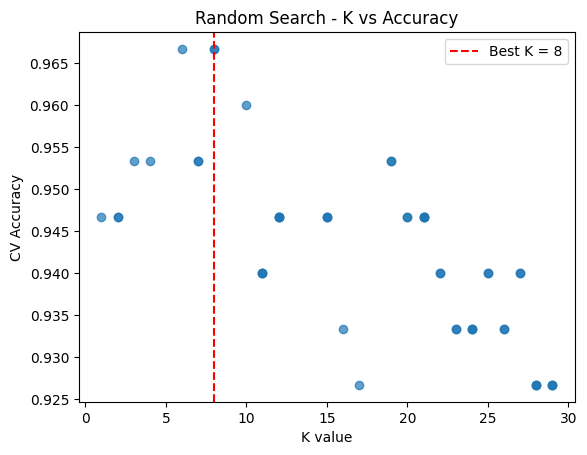

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
# visualise random search results
ks, scores = zip(*results)
plt.scatter(ks, scores, alpha=0.7)
plt.axvline(best_k, color='red', linestyle='--',
            label=f'Best K = {best_k}')
plt.xlabel('K value')
plt.ylabel('CV Accuracy')
plt.title('Random Search - K vs Accuracy')
plt.legend()
plt.show()

# final model with best K
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))